# LAB Redes Neurais

## Perceptron - Experimento 1

EXPERIMENTO 1: Impacto de Diferentes Inicializações

Inicialização com seed=1:
Convergiu em 2 iterações!

Inicialização com seed=42:
Convergiu em 2 iterações!

Inicialização com seed=100:
Convergiu em 2 iterações!


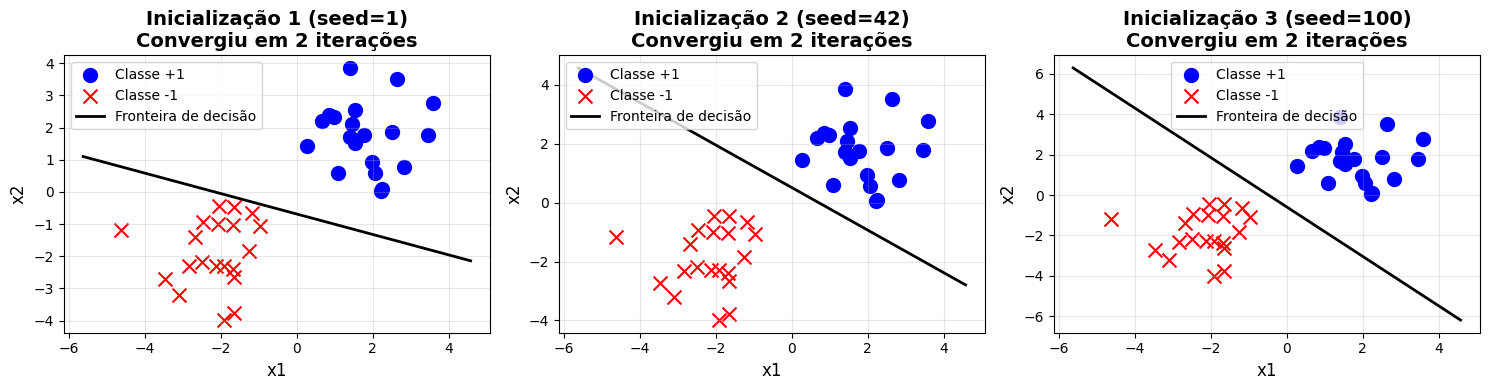


Observe que todas as fronteiras separam corretamente os dados,
mas têm orientações diferentes devido às inicializações distintas!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, learning_rate=0.1, max_iterations=100, random_seed=None):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.random_seed = random_seed
        self.weights = None
        self.bias = None
        self.iterations_to_converge = None

    def fit(self, X, y):
        """
        Treina o perceptron
        X: dados de entrada (n_samples, n_features)
        y: rótulos {-1, 1}
        """
        if self.random_seed is not None:
            np.random.seed(self.random_seed)

        n_samples, n_features = X.shape

        # Inicialização dos pesos e bias
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = np.random.randn() * 0.01

        # Treinamento
        for iteration in range(self.max_iterations):
            errors = 0

            for i in range(n_samples):
                # Calcula a saída
                linear_output = np.dot(X[i], self.weights) + self.bias
                prediction = np.sign(linear_output)

                # Atualiza pesos se houver erro
                if prediction != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1

            # Convergiu se não houver erros
            if errors == 0:
                self.iterations_to_converge = iteration + 1
                print(f"Convergiu em {self.iterations_to_converge} iterações!")
                break
        else:
            self.iterations_to_converge = self.max_iterations
            print(f"Não convergiu em {self.max_iterations} iterações")

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.sign(linear_output)

    def get_decision_boundary(self):
        """Retorna os parâmetros da fronteira de decisão"""
        return self.weights, self.bias


def plot_decision_boundary(X, y, perceptron, title, ax):
    """Plota os dados e a fronteira de decisão"""
    # Plota os pontos
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='o', label='Classe +1', s=100)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], color='red', marker='x', label='Classe -1', s=100)

    # Plota a fronteira de decisão
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1

    if perceptron.weights[1] != 0:
        # Equação da reta: w1*x1 + w2*x2 + b = 0
        # x2 = -(w1*x1 + b) / w2
        x1_boundary = np.array([x_min, x_max])
        x2_boundary = -(perceptron.weights[0] * x1_boundary + perceptron.bias) / perceptron.weights[1]
        ax.plot(x1_boundary, x2_boundary, 'k-', linewidth=2, label='Fronteira de decisão')

    ax.set_xlabel('x1', fontsize=12)
    ax.set_ylabel('x2', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)


# ====== EXPERIMENTO 1: Diferentes Inicializações ======
print("=" * 60)
print("EXPERIMENTO 1: Impacto de Diferentes Inicializações")
print("=" * 60)

# Gera dados linearmente separáveis
np.random.seed(42)
X1 = np.random.randn(20, 2) + np.array([2, 2])
X2 = np.random.randn(20, 2) + np.array([-2, -2])
X = np.vstack([X1, X2])
y = np.hstack([np.ones(20), -np.ones(20)])

# Treina com 3 inicializações diferentes
seeds = [1, 42, 100]
perceptrons = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, seed in enumerate(seeds):
    print(f"\nInicialização com seed={seed}:")
    p = Perceptron(learning_rate=0.1, max_iterations=100, random_seed=seed)
    p.fit(X, y)
    perceptrons.append(p)

    plot_decision_boundary(X, y, p,
                          f'Inicialização {idx+1} (seed={seed})\nConvergiu em {p.iterations_to_converge} iterações',
                          axes[idx])

plt.tight_layout()
plt.savefig('diferentes_inicializacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("Observe que todas as fronteiras separam corretamente os dados,")
print("mas têm orientações diferentes devido às inicializações distintas!")
print("=" * 80)



#### Neste experimento usamos três inicializações diferentes (seeds 1, 42 e 100) e obtivemos três fronteiras de decisão com orientações distintas. Todas elas classificam corretamente os dados de treinamento.
#### Pergunta: Por que o perceptron encontra fronteiras de decisão diferentes quando mudamos apenas a inicialização dos pesos? Isso significa que o algoritmo está funcionando de forma incorreta? Justifique sua resposta.

## Perceptron - Experimento 2


EXPERIMENTO 2: Convergência Garantida

Dados Linearmente Separáveis:
Convergiu em 2 iterações!

Dados NÃO Linearmente Separáveis (XOR):
Não convergiu em 100 iterações


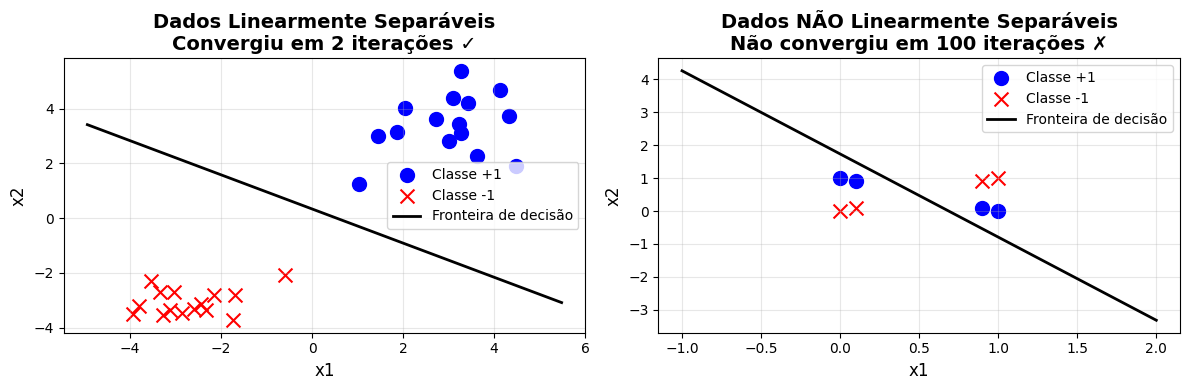


CONCLUSÃO:
- Dados linearmente separáveis: CONVERGÊNCIA GARANTIDA!
- Dados não linearmente separáveis: NÃO CONVERGE


In [ ]:

# ====== EXPERIMENTO 2: Convergência em Dados Linearmente Separáveis ======
print("\n" + "=" * 60)
print("EXPERIMENTO 2: Convergência Garantida")
print("=" * 60)

# Dados claramente separáveis
np.random.seed(10)
X1_sep = np.random.randn(15, 2) + np.array([3, 3])
X2_sep = np.random.randn(15, 2) + np.array([-3, -3])
X_sep = np.vstack([X1_sep, X2_sep])
y_sep = np.hstack([np.ones(15), -np.ones(15)])

# Dados não linearmente separáveis (XOR)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1],
                  [0.1, 0.1], [0.1, 0.9], [0.9, 0.1], [0.9, 0.9]])
y_xor = np.array([-1, 1, 1, -1, -1, 1, 1, -1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Treina no conjunto separável
print("\nDados Linearmente Separáveis:")
p_sep = Perceptron(learning_rate=0.1, max_iterations=100, random_seed=42)
p_sep.fit(X_sep, y_sep)
plot_decision_boundary(X_sep, y_sep, p_sep,
                      f'Dados Linearmente Separáveis\nConvergiu em {p_sep.iterations_to_converge} iterações ✓',
                      axes[0])

# Treina no conjunto XOR (não separável)
print("\nDados NÃO Linearmente Separáveis (XOR):")
p_xor = Perceptron(learning_rate=0.1, max_iterations=100, random_seed=42)
p_xor.fit(X_xor, y_xor)
plot_decision_boundary(X_xor, y_xor, p_xor,
                      f'Dados NÃO Linearmente Separáveis\nNão convergiu em {p_xor.max_iterations} iterações ✗',
                      axes[1])

plt.tight_layout()
plt.savefig('convergencia.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("CONCLUSÃO:")
print("- Dados linearmente separáveis: CONVERGÊNCIA GARANTIDA!")
print("- Dados não linearmente separáveis: NÃO CONVERGE")
print("=" * 60)

#### No Experimento 2, vimos dois cenários: dados linearmente separáveis (que convergiu rapidamente) e dados do tipo XOR (que não convergiu mesmo após 100 iterações).
#### Pergunta: Olhando para o gráfico dos dados XOR, explique com suas palavras por que é impossível para o perceptron encontrar uma única linha reta que separe corretamente as classes. O que isso nos ensina sobre as limitações do perceptron?

## Multi-Layer Perceptron

### Capacidade do MLP em problemas não-lineares

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons, make_circles
import warnings

# Silencia warnings específicos do sklearn
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='divide by zero encountered')
warnings.filterwarnings('ignore', module='sklearn')

class MLPLab:

    def __init__(self):
        self.models = {}
        self.datasets = {}

    def create_datasets(self):
        """Cria diferentes conjuntos de dados para demonstração"""
        np.random.seed(42)

        # 1. Problema XOR (clássico problema não-linear)
        X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
        y_xor = np.array([0, 1, 1, 0])

        # Adiciona mais pontos ao redor para melhor visualização
        noise_xor = np.random.randn(40, 2) * 0.1
        X_xor_extra = np.vstack([
            [0, 0] + noise_xor[:10],
            [0, 1] + noise_xor[10:20],
            [1, 0] + noise_xor[20:30],
            [1, 1] + noise_xor[30:40]
        ])
        y_xor_extra = np.array([0]*10 + [1]*10 + [1]*10 + [0]*10)

        # 2. Círculos concêntricos
        X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

        # 3. Luas entrelaçadas
        X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)

        # 4. Espiral (problema muito desafiador)
        n_points = 100
        theta = np.sqrt(np.random.rand(n_points)) * 2 * np.pi

        r_a = 2 * theta + np.pi
        data_a = np.array([np.cos(theta) * r_a, np.sin(theta) * r_a]).T
        x_a = data_a + np.random.randn(n_points, 2) * 0.2

        r_b = -2 * theta - np.pi
        data_b = np.array([np.cos(theta) * r_b, np.sin(theta) * r_b]).T
        x_b = data_b + np.random.randn(n_points, 2) * 0.2

        X_spiral = np.vstack([x_a, x_b])
        y_spiral = np.hstack([np.zeros(n_points), np.ones(n_points)])

        self.datasets = {
            'XOR': (X_xor_extra, y_xor_extra),
            'Círculos': (X_circles, y_circles),
            'Luas': (X_moons, y_moons),
            'Espiral': (X_spiral, y_spiral)
        }

        return self.datasets

    def train_mlp(self, X, y, hidden_layers, name, max_iter=2000):
        """Treina um MLP com a arquitetura especificada"""
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation='relu',
            solver='adam',
            max_iter=max_iter,
            random_state=42,
            learning_rate_init=0.01
        )

        mlp.fit(X, y)
        accuracy = mlp.score(X, y)

        print(f"{name}: Acurácia = {accuracy:.2%} | Iterações = {mlp.n_iter_}")

        return mlp, accuracy

    def plot_decision_boundary(self, X, y, model, title, ax):
        """Plota a fronteira de decisão do modelo"""
        h = 0.02  # tamanho do passo na malha

        # Cria uma malha
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))

        # Prediz para cada ponto da malha
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plota a fronteira de decisão
        cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
        cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

        ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold,
                  edgecolor='black', s=50, alpha=0.8)

        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.grid(True, alpha=0.3)

    def compare_architectures(self, dataset_name='XOR'):
        """Compara diferentes arquiteturas de MLP"""
        X, y = self.datasets[dataset_name]

        architectures = [
            ((), 'Sem camada oculta\n(Equivalente ao Perceptron)'),
            ((2,), '1 camada: 2 neurônios'),
            ((4,), '1 camada: 4 neurônios'),
            ((8,), '1 camada: 8 neurônios')
        ]

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()

        print(f"\n{'='*60}")
        print(f"COMPARAÇÃO DE ARQUITETURAS - Dataset: {dataset_name}")
        print(f"{'='*60}\n")

        for idx, (arch, desc) in enumerate(architectures):
            mlp, acc = self.train_mlp(X, y, arch, desc)
            title = f"{desc}\nAcurácia: {acc:.2%}"
            self.plot_decision_boundary(X, y, mlp, title, axes[idx])

        plt.tight_layout()
        plt.savefig(f'mlp_architectures_{dataset_name}.png', dpi=150, bbox_inches='tight')
        plt.show()

    def demonstrate_all_problems(self):
        """Demonstra MLP em todos os problemas não-lineares"""
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))

        print(f"\n{'='*60}")
        print("DEMONSTRAÇÃO: MLP vs Problemas Não-Lineares")
        print(f"{'='*60}\n")

        for idx, (name, (X, y)) in enumerate(self.datasets.items()):
            # Perceptron (sem camada oculta)
            print(f"\n--- {name} ---")
            print("Tentando com Perceptron (sem camada oculta):")
            mlp_linear, acc_linear = self.train_mlp(X, y, (), "Perceptron")

            # MLP com camadas ocultas
            print(f"Tentando com MLP (2 camadas ocultas):")
            mlp_nonlinear, acc_nonlinear = self.train_mlp(X, y, (10, 5), "MLP")

            # Plota comparação
            self.plot_decision_boundary(X, y, mlp_linear,
                                       f'{name}\nPerceptron: {acc_linear:.2%}',
                                       axes[0, idx])

            self.plot_decision_boundary(X, y, mlp_nonlinear,
                                       f'{name}\nMLP: {acc_nonlinear:.2%}',
                                       axes[1, idx])

        axes[0, 0].set_ylabel('SEM Camada Oculta\n(Linear)',
                             fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('COM Camadas Ocultas\n(Não-Linear)',
                             fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.savefig('mlp_vs_perceptron_all.png', dpi=150, bbox_inches='tight')
        plt.show()

    def visualize_learning_process(self, dataset_name='Luas'):
        """Visualiza o processo de aprendizado ao longo das iterações"""
        X, y = self.datasets[dataset_name]

        iterations = [1, 5, 20, 100, 500, 2000]
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()

        print(f"\n{'='*60}")
        print(f"PROCESSO DE APRENDIZADO - Dataset: {dataset_name}")
        print(f"{'='*60}\n")

        for idx, n_iter in enumerate(iterations):
            mlp = MLPClassifier(
                hidden_layer_sizes=(10, 5),
                activation='relu',
                solver='adam',
                max_iter=n_iter,
                random_state=42,
                learning_rate_init=0.01
            )

            mlp.fit(X, y)
            acc = mlp.score(X, y)

            print(f"Após {n_iter} iterações: Acurácia = {acc:.2%}")

            title = f'Após {n_iter} iterações\nAcurácia: {acc:.2%}'
            self.plot_decision_boundary(X, y, mlp, title, axes[idx])

        plt.tight_layout()
        plt.savefig(f'mlp_learning_process_{dataset_name}.png', dpi=150, bbox_inches='tight')
        plt.show()

    def activation_function_comparison(self, dataset_name='Círculos'):
        """Compara diferentes funções de ativação"""
        X, y = self.datasets[dataset_name]

        activations = ['identity', 'logistic', 'tanh', 'relu']
        activation_names = {
            'identity': 'Linear (identity)',
            'logistic': 'Sigmoide (logistic)',
            'tanh': 'Tangente Hiperbólica',
            'relu': 'ReLU'
        }

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.ravel()

        print(f"\n{'='*60}")
        print(f"COMPARAÇÃO DE FUNÇÕES DE ATIVAÇÃO - Dataset: {dataset_name}")
        print(f"{'='*60}\n")

        for idx, activation in enumerate(activations):
            mlp = MLPClassifier(
                hidden_layer_sizes=(10, 5),
                activation=activation,
                solver='adam',
                max_iter=2000,
                random_state=42,
                learning_rate_init=0.01
            )

            mlp.fit(X, y)
            acc = mlp.score(X, y)

            print(f"{activation_names[activation]}: Acurácia = {acc:.2%}")

            title = f'{activation_names[activation]}\nAcurácia: {acc:.2%}'
            self.plot_decision_boundary(X, y, mlp, title, axes[idx])

        plt.tight_layout()
        plt.savefig(f'mlp_activation_functions_{dataset_name}.png', dpi=150, bbox_inches='tight')
        plt.show()




### Experimento 1

LABORATÓRIO: Multi-Layer Perceptron (MLP)
Demonstrando a capacidade de resolver problemas não-lineares

Criando datasets não-lineares...


EXPERIMENTO 1: MLP vs Perceptron
Comparando modelos lineares e não-lineares em 4 problemas

DEMONSTRAÇÃO: MLP vs Problemas Não-Lineares


--- XOR ---
Tentando com Perceptron (sem camada oculta):
Perceptron: Acurácia = 50.00% | Iterações = 182
Tentando com MLP (2 camadas ocultas):
MLP: Acurácia = 100.00% | Iterações = 202

--- Círculos ---
Tentando com Perceptron (sem camada oculta):
Perceptron: Acurácia = 51.50% | Iterações = 138
Tentando com MLP (2 camadas ocultas):
MLP: Acurácia = 99.50% | Iterações = 345

--- Luas ---
Tentando com Perceptron (sem camada oculta):
Perceptron: Acurácia = 85.00% | Iterações = 790
Tentando com MLP (2 camadas ocultas):
MLP: Acurácia = 89.50% | Iterações = 403

--- Espiral ---
Tentando com Perceptron (sem camada oculta):
Perceptron: Acurácia = 75.00% | Iterações = 146
Tentando com MLP (2 camadas ocultas):
MLP: Acurácia 

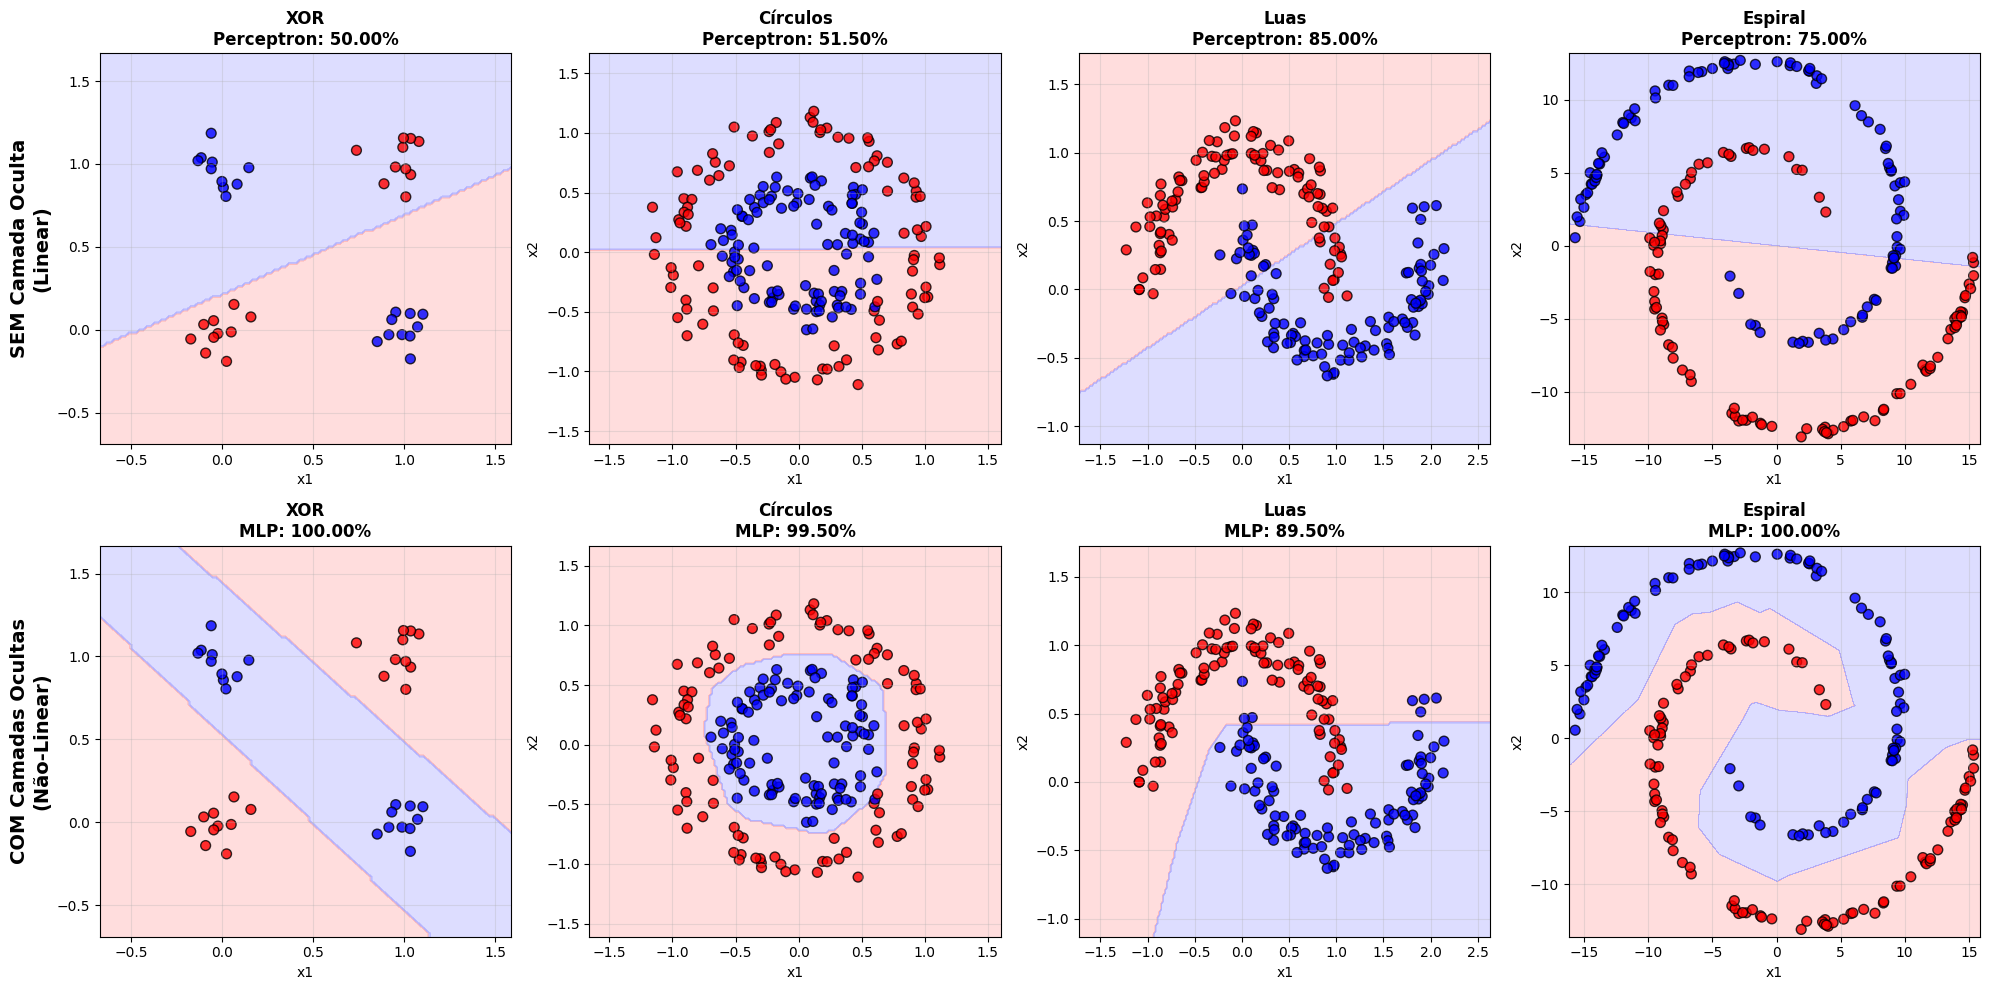

In [ ]:
# ====== EXECUÇÃO DO LABORATÓRIO ======

print("="*60)
print("LABORATÓRIO: Multi-Layer Perceptron (MLP)")
print("Demonstrando a capacidade de resolver problemas não-lineares")
print("="*60)

# Cria o laboratório
lab = MLPLab()

# Cria os datasets
print("\nCriando datasets não-lineares...")
lab.create_datasets()

# Experimento 1: Comparação MLP vs Perceptron em todos os problemas
print("\n\nEXPERIMENTO 1: MLP vs Perceptron")
print("Comparando modelos lineares e não-lineares em 4 problemas")
lab.demonstrate_all_problems()




#### Observe o Experimento 1, especialmente o problema XOR.
#### a) Explique por que o Perceptron (sem camada oculta) não consegue resolver o problema XOR, enquanto o MLP com camadas ocultas consegue.
#### b) Olhando para as fronteiras de decisão do MLP nos 4 problemas, descreva com suas palavras o tipo de fronteira que o MLP consegue criar (reta, curva, complexa?). Como isso é diferente do Perceptron?


### Experimento 2



EXPERIMENTO 3: Processo de Aprendizado
Observando como a fronteira de decisão evolui

PROCESSO DE APRENDIZADO - Dataset: Luas

Após 1 iterações: Acurácia = 50.00%
Após 5 iterações: Acurácia = 50.00%
Após 20 iterações: Acurácia = 50.00%
Após 100 iterações: Acurácia = 87.00%
Após 500 iterações: Acurácia = 89.50%
Após 2000 iterações: Acurácia = 89.50%


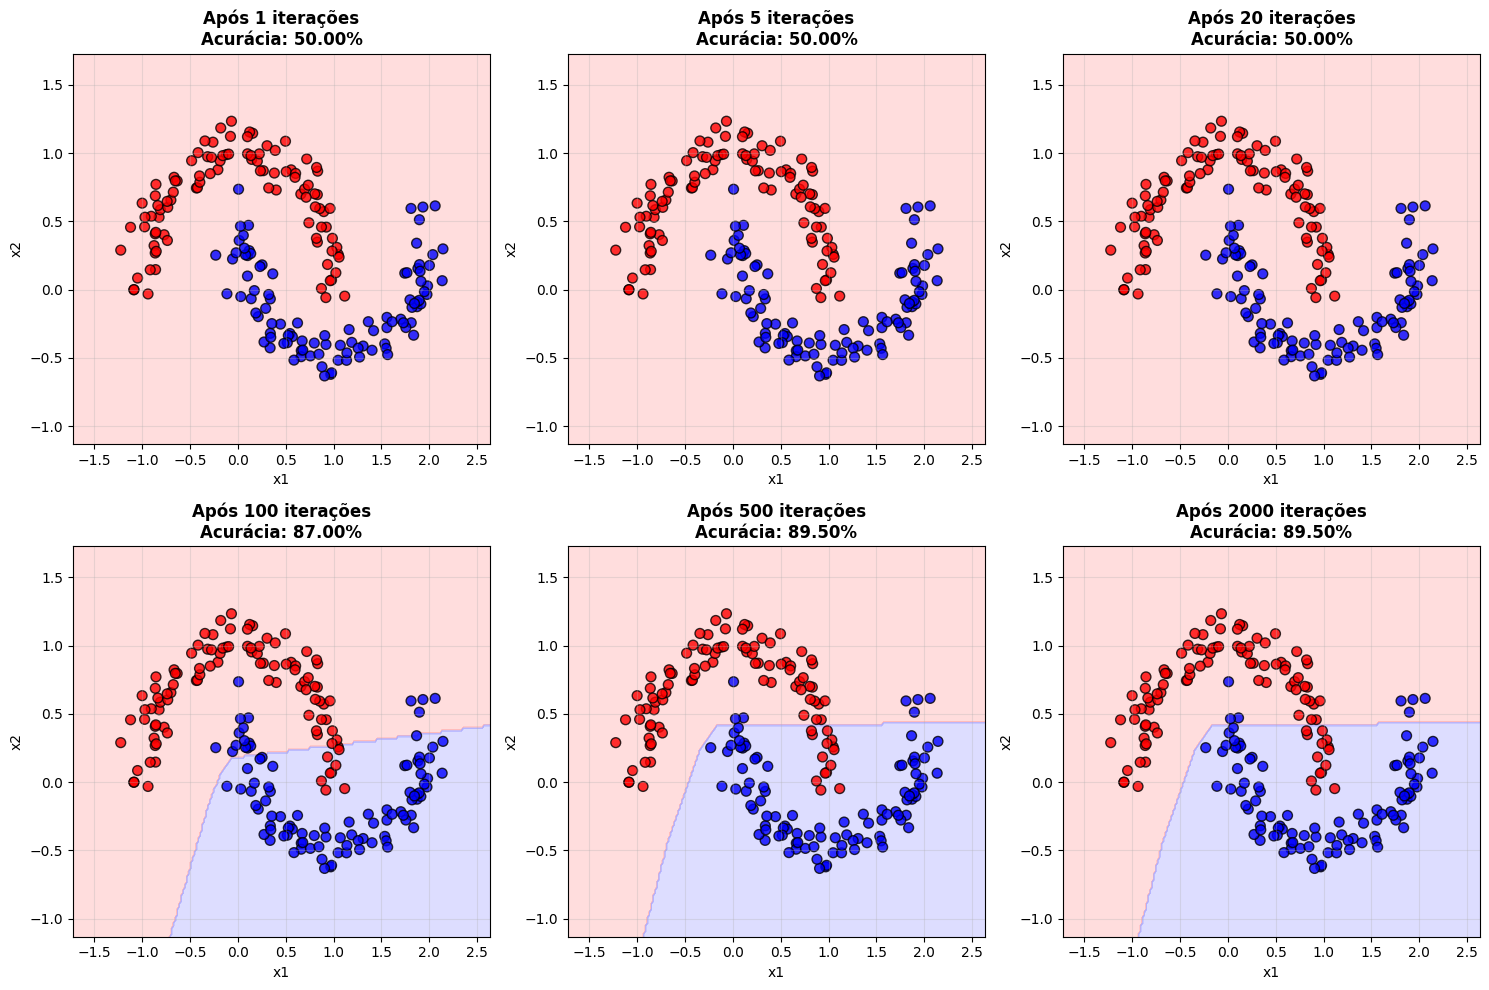

In [ ]:
# Experimento 3: Processo de aprendizado
print("\n\nEXPERIMENTO 3: Processo de Aprendizado")
print("Observando como a fronteira de decisão evolui")
lab.visualize_learning_process('Luas')



### Experimento 3



EXPERIMENTO 4: Funções de Ativação
Comparando diferentes funções de ativação

COMPARAÇÃO DE FUNÇÕES DE ATIVAÇÃO - Dataset: Círculos

Linear (identity): Acurácia = 50.00%
Sigmoide (logistic): Acurácia = 50.00%
Tangente Hiperbólica: Acurácia = 99.50%
ReLU: Acurácia = 99.50%


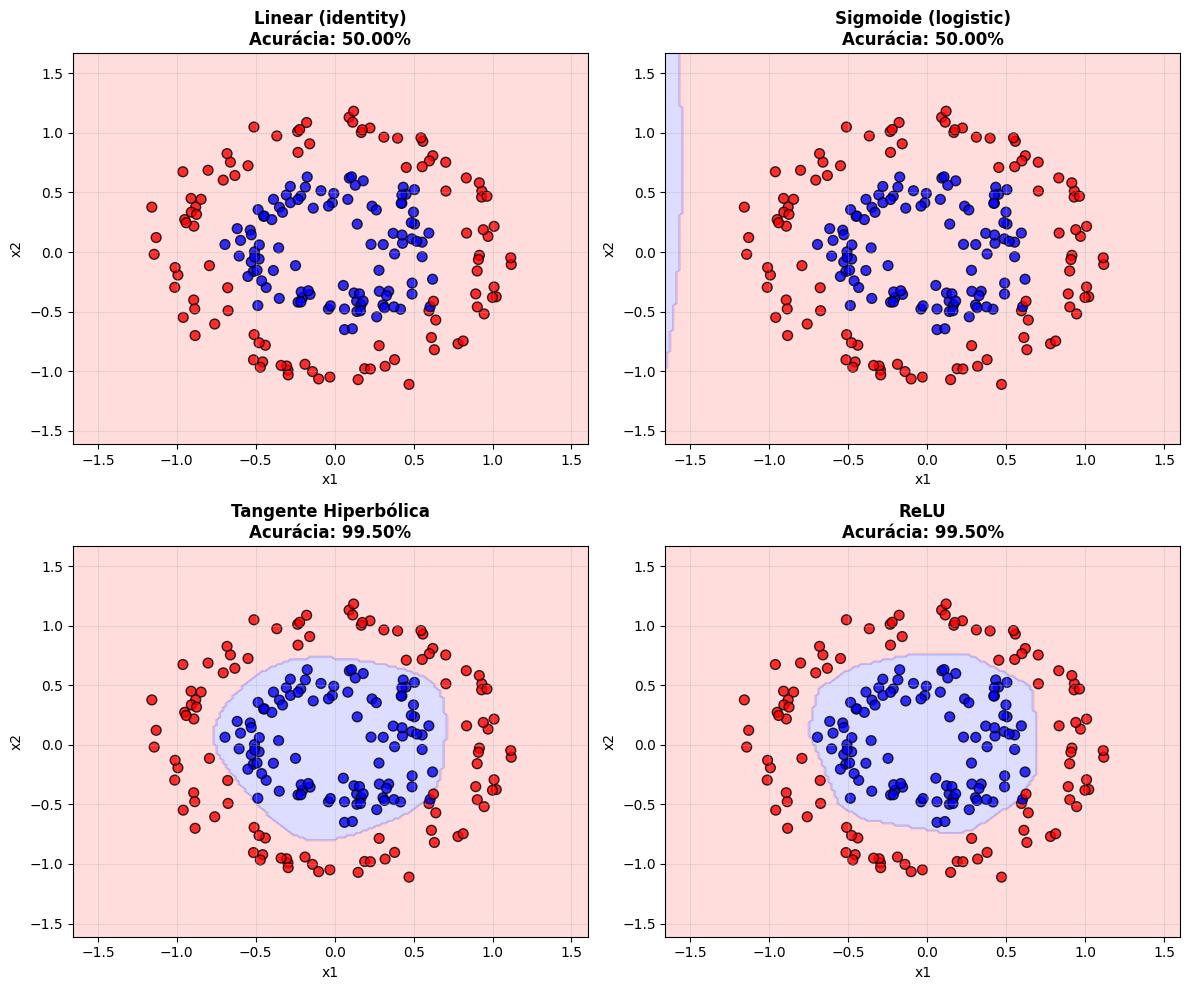

In [ ]:
# Experimento 4: Funções de ativação
print("\n\nEXPERIMENTO 4: Funções de Ativação")
print("Comparando diferentes funções de ativação")
lab.activation_function_comparison('Círculos')


#### No Experimento 4, comparamos 4 funções de ativação: Linear, Sigmoide, Tanh e ReLU.
#### a) Por que a função de ativação linear (identity) falhou em resolver o problema, enquanto as outras três tiveram sucesso?
#### b) Observando as visualizações, você nota alguma diferença nas fronteiras de decisão criadas por Sigmoide, Tanh e ReLU? Todas têm acurácia similar?
#### c) Na prática, ReLU é a função de ativação mais popular atualmente. Isso quer dizer que sempre devemos usá-la? (DICA: veja o próximo experimento)






EXPERIMENTO 5: Funções de Ativação
Comparando diferentes funções de ativação

COMPARAÇÃO DE FUNÇÕES DE ATIVAÇÃO - Dataset: Luas

Linear (identity): Acurácia = 86.00%
Sigmoide (logistic): Acurácia = 86.00%
Tangente Hiperbólica: Acurácia = 100.00%
ReLU: Acurácia = 89.50%


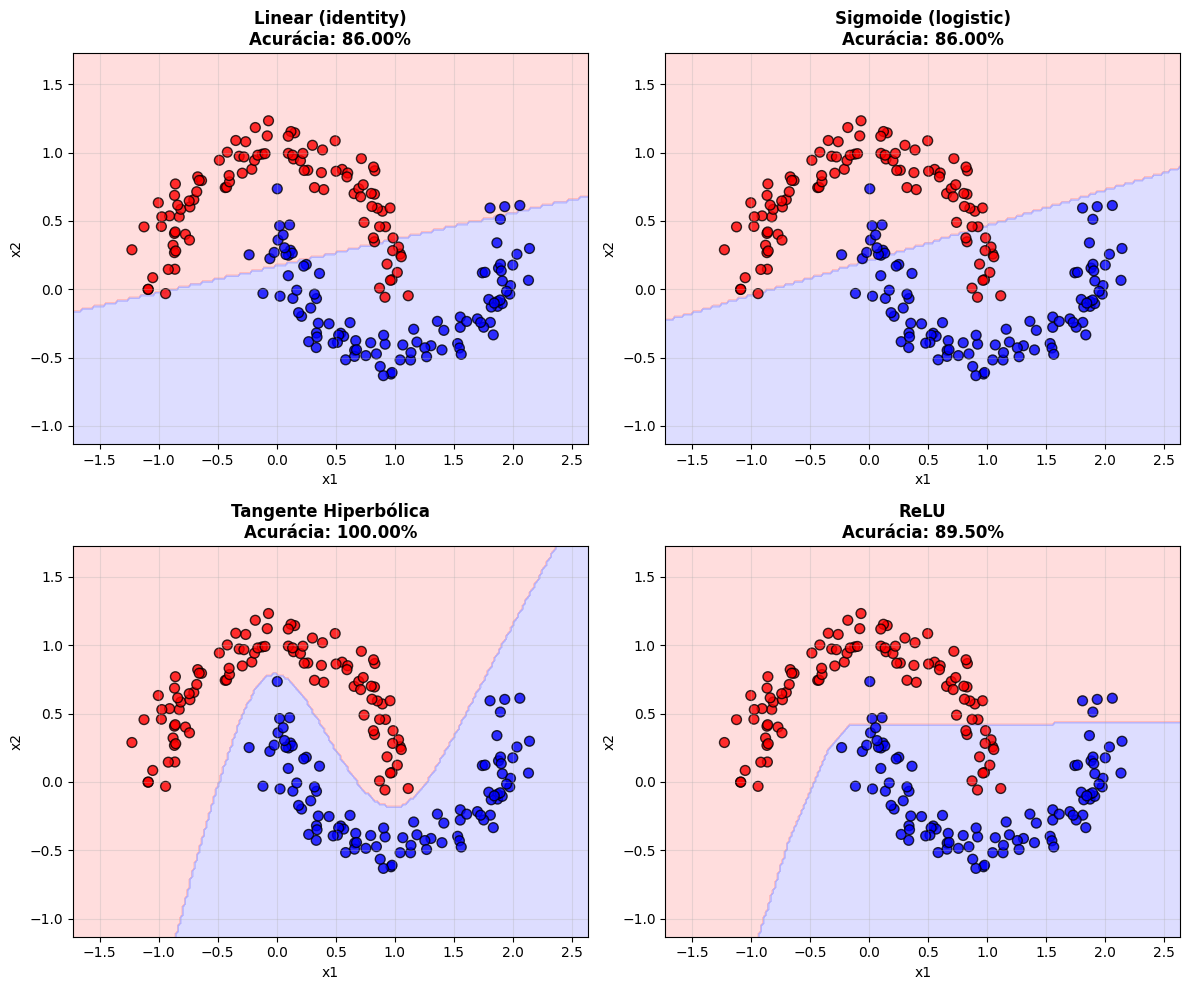

In [ ]:
# Experimento 5: Funções de ativação
print("\n\nEXPERIMENTO 5: Funções de Ativação")
print("Comparando diferentes funções de ativação")
lab.activation_function_comparison('Luas')